<a href="https://colab.research.google.com/github/AhmadKhdair/BinX-AI-ML-Internship/blob/main/week-7/d1/01_Sprint2_Convolution_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 - Day 1: Sprint 2 Planning and Convolution Demo

This notebook starts Week 7 with the image dataset attached for the sprint work. The goal for Day 1 is not to train a full CNN yet. The goal is to understand why images need convolution, apply one hand-defined edge filter, inspect the resulting feature map, and record the architecture decision for this dataset.

The dataset is organized as a binary image-classification task with two classes: `Benign` and `Malignant`.

## 1. Sprint 2 Plan

### Sprint Goal

Use the image dataset to move from general neural networks into computer-vision models. For this sprint, the main direction is to build toward a CNN-based classifier because the input is image data with spatial structure.

### Day 1 Backlog

| Task | Acceptance Criteria |
|---|---|
| Verify the uploaded image dataset | Confirm the split folders, class folders, number of images, image size, and color mode |
| Explain why dense layers are inefficient for raw images | Compare parameter counts for a dense layer and a convolution layer |
| Apply a hand-defined convolution filter | Use a fixed edge-detection kernel on a real sample image |
| Visualize the feature map | Show the original image and the convolution output side by side |
| Record the architecture decision | Decide whether the dataset calls for CNN, RNN/Transformer, or dense-only modeling |

The full CNN training work starts after this. Today I am keeping the implementation focused on convolution itself.

## 2. Imports and Dataset Path

The notebook can run in two ways:

- locally, if the dataset archive is already available;
- in Google Colab, by uploading the zip file when the notebook asks for it.

I am keeping the archive zipped for the audit step because Day 1 only needs to inspect and sample images, not train from the whole folder.

In [1]:
from pathlib import Path
from collections import Counter
import io
import os
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = False

cwd = Path.cwd().resolve()

In [2]:
def running_in_colab():
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False


def find_dataset_archive():
    env_path = os.environ.get("WEEK7_IMAGE_ARCHIVE")
    candidates = []

    if env_path:
        candidates.append(Path(env_path).expanduser())

    candidates.extend([
        cwd / "archive.zip",
        cwd / "archive (3).zip",
        cwd / "dataset.zip",
        cwd / "data" / "archive.zip",
        cwd / "data" / "archive (3).zip",
        cwd / "data" / "dataset.zip",
    ])

    for path in candidates:
        if path.exists() and path.suffix.lower() == ".zip":
            return path.resolve()

    local_zips = sorted(cwd.glob("*.zip")) + sorted((cwd / "data").glob("*.zip")) if (cwd / "data").exists() else sorted(cwd.glob("*.zip"))
    if local_zips:
        return local_zips[0].resolve()

    if running_in_colab():
        from google.colab import files  # type: ignore
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("No zip file was uploaded.")
        first_name = next(iter(uploaded))
        return (cwd / first_name).resolve()

    raise FileNotFoundError(
        "Dataset archive was not found. Put the zip file beside the notebook, "
        "or set WEEK7_IMAGE_ARCHIVE to its full path."
    )


DATASET_ZIP = find_dataset_archive()
print("Dataset archive:", DATASET_ZIP)

Saving archive (3).zip to archive (3).zip
Dataset archive: /content/archive (3).zip


## 3. Dataset Audit

Before applying convolution, I first check that the archive structure matches an image-classification dataset. The expected layout is split folders, then class folders, then image files.

In [3]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

with zipfile.ZipFile(DATASET_ZIP) as zf:
    image_files = [
        name for name in zf.namelist()
        if not name.endswith("/") and Path(name).suffix.lower() in IMAGE_EXTENSIONS
    ]

if not image_files:
    raise ValueError("No image files were found inside the dataset archive.")

records = []
for name in image_files:
    parts = Path(name).parts
    if len(parts) >= 3:
        split, label = parts[0], parts[1]
    else:
        split, label = "unknown", "unknown"
    records.append({"path": name, "split": split, "label": label})

files_df = pd.DataFrame(records)
summary = (
    files_df.groupby(["split", "label"])
    .size()
    .rename("images")
    .reset_index()
    .sort_values(["split", "label"])
)

display(summary)
print("Total images:", len(files_df))

,split,label,images
0,test,Benign,1000
1,test,Malignant,1000
2,train,Benign,6289
3,train,Malignant,5590


Total images: 13879


In [4]:
def read_image_from_zip(path):
    with zipfile.ZipFile(DATASET_ZIP) as zf:
        with zf.open(path) as image_file:
            return Image.open(io.BytesIO(image_file.read())).convert("RGB")

sampled_for_audit = (
    files_df.groupby(["split", "label"], group_keys=False)
    .sample(n=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

shape_records = []
for path in sampled_for_audit["path"]:
    image = read_image_from_zip(path)
    shape_records.append({
        "path": path,
        "width": image.size[0],
        "height": image.size[1],
        "mode": image.mode,
    })

shape_audit = pd.DataFrame(shape_records)
display(shape_audit)

,path,width,height,mode
0,test/Benign/6821.jpg,224,224,RGB
1,test/Malignant/5695.jpg,224,224,RGB
2,train/Benign/4647.jpg,224,224,RGB
3,train/Malignant/4752.jpg,224,224,RGB


The audit confirms the important input shape for this work: the images are RGB, so one image is represented as `height x width x 3`. The third dimension is the three color channels. For this dataset, the sampled images use `224 x 224 x 3`.

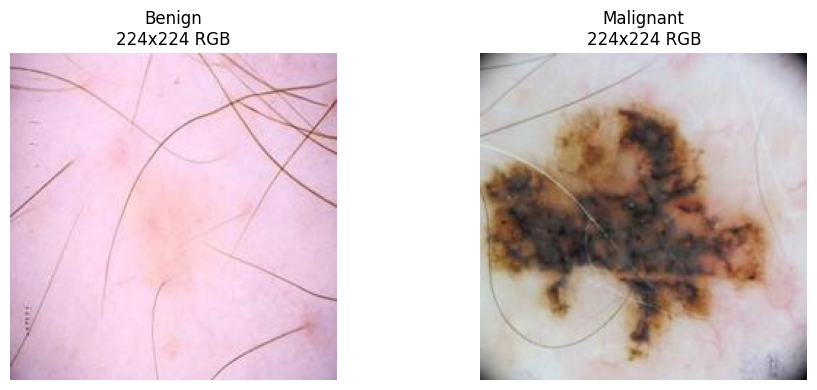

In [5]:
train_samples = (
    files_df[files_df["split"].str.lower() == "train"]
    .groupby("label", group_keys=False)
    .sample(n=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, len(train_samples), figsize=(10, 4))
if len(train_samples) == 1:
    axes = [axes]

for ax, row in zip(axes, train_samples.itertuples(index=False)):
    image = read_image_from_zip(row.path)
    ax.imshow(image)
    ax.set_title(f"{row.label}\n{image.size[0]}x{image.size[1]} RGB")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Why a Dense Layer Is Not the Right First Move for Images

A dense layer treats the flattened image as one long vector. For a `224 x 224 x 3` image, that is `150,528` input values. If the first hidden layer has only 64 units, the first layer alone needs millions of weights.

Convolution keeps the spatial layout. A small kernel looks at a local region, then the same kernel is reused across the image. That is the main reason CNNs are much more practical for image data.

In [6]:
height, width, channels = 224, 224, 3
flattened_inputs = height * width * channels
hidden_units = 64

first_dense_params = flattened_inputs * hidden_units + hidden_units

kernel_h, kernel_w = 3, 3
filters = 16
conv_params = kernel_h * kernel_w * channels * filters + filters

parameter_comparison = pd.DataFrame(
    {
        "layer": ["Dense on flattened image", "Conv2D with 16 filters"],
        "calculation": [
            f"({height}*{width}*{channels})*{hidden_units} + {hidden_units}",
            f"({kernel_h}*{kernel_w}*{channels})*{filters} + {filters}",
        ],
        "parameters": [first_dense_params, conv_params],
    }
)

parameter_comparison["times_more_than_conv"] = (
    parameter_comparison["parameters"] / conv_params
).round(2)

display(parameter_comparison)

,layer,calculation,parameters,times_more_than_conv
0,Dense on flattened image,(224*224*3)*64 + 64,9633856,21504.14
1,Conv2D with 16 filters,(3*3*3)*16 + 16,448,1.00


The dense layer has many more parameters because every input value gets its own weight for every hidden unit. The convolution layer has far fewer parameters because each filter has one small set of weights, then those same weights are applied at all image locations.

This is parameter sharing. It means the model can learn a pattern once, such as an edge or texture, and search for it across the whole image instead of learning separate weights for every possible position.

## 5. Hand-Defined Convolution Filter

For the Day 1 demo, I am not learning the filter from data. I define a simple edge-detection kernel manually, then slide it over one real image from the dataset.

The operation is the same idea used inside a CNN layer: take a small region, multiply it by the kernel values, sum the result, move to the next location, and repeat.

In [7]:
def rgb_to_grayscale_array(image):
    rgb = np.asarray(image).astype(np.float32) / 255.0
    return 0.299 * rgb[:, :, 0] + 0.587 * rgb[:, :, 1] + 0.114 * rgb[:, :, 2]


def convolve2d(image_2d, kernel, stride=1, padding="valid"):
    if image_2d.ndim != 2:
        raise ValueError("convolve2d expects a single-channel 2D image.")
    if kernel.ndim != 2:
        raise ValueError("kernel must be 2D.")
    if stride < 1:
        raise ValueError("stride must be >= 1.")
    if padding not in {"valid", "same"}:
        raise ValueError("padding must be 'valid' or 'same'.")

    kernel_h, kernel_w = kernel.shape
    if padding == "same":
        pad_h = kernel_h // 2
        pad_w = kernel_w // 2
        padded = np.pad(image_2d, ((pad_h, pad_h), (pad_w, pad_w)), mode="constant")
    else:
        padded = image_2d

    out_h = (padded.shape[0] - kernel_h) // stride + 1
    out_w = (padded.shape[1] - kernel_w) // stride + 1
    if out_h <= 0 or out_w <= 0:
        raise ValueError("Kernel is larger than the image for the selected padding.")

    output = np.empty((out_h, out_w), dtype=np.float32)
    for row in range(out_h):
        for col in range(out_w):
            row_start = row * stride
            col_start = col * stride
            patch = padded[row_start:row_start + kernel_h, col_start:col_start + kernel_w]
            output[row, col] = np.sum(patch * kernel)

    return output

In [8]:
preferred_sample = train_samples.iloc[0]["path"] if len(train_samples) else files_df.iloc[0]["path"]
sample_image = read_image_from_zip(preferred_sample)
gray_image = rgb_to_grayscale_array(sample_image)

vertical_edge_kernel = np.array(
    [
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1],
    ],
    dtype=np.float32,
)

feature_map = convolve2d(gray_image, vertical_edge_kernel, stride=1, padding="same")

print("Sample image path:", preferred_sample)
print("RGB image shape:", np.asarray(sample_image).shape)
print("Grayscale shape:", gray_image.shape)
print("Kernel shape:", vertical_edge_kernel.shape)
print("Feature map shape:", feature_map.shape)

Sample image path: train/Benign/5000.jpg
RGB image shape: (224, 224, 3)
Grayscale shape: (224, 224)
Kernel shape: (3, 3)
Feature map shape: (224, 224)


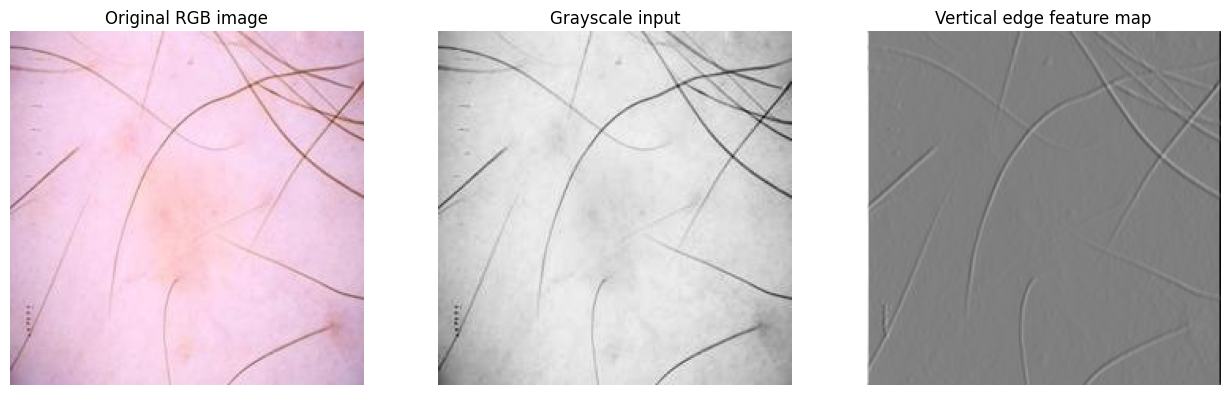

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(sample_image)
axes[0].set_title("Original RGB image")
axes[0].axis("off")

axes[1].imshow(gray_image, cmap="gray")
axes[1].set_title("Grayscale input")
axes[1].axis("off")

abs_max = np.max(np.abs(feature_map))
axes[2].imshow(feature_map, cmap="gray", vmin=-abs_max, vmax=abs_max)
axes[2].set_title("Vertical edge feature map")
axes[2].axis("off")

plt.tight_layout()
plt.show()

The feature map is not a class prediction. It is only the response of one filter at each image location. Strong bright or dark areas mean the local patch matched the edge pattern strongly in one direction or the opposite direction.

In a trained CNN, the filter values would be learned by backpropagation from the final classification loss. Here the values are fixed by hand just to make the convolution operation visible.

## 6. Stride and Padding

Stride controls how far the kernel moves each step. Padding controls whether the convolution can also place the kernel around the image borders.

For this demo, `same` padding keeps the feature map aligned with the original image size when stride is 1. `valid` padding uses only positions where the full kernel fits inside the image.

In [10]:
shape_examples = []
for padding in ["valid", "same"]:
    for stride in [1, 2]:
        result = convolve2d(gray_image, vertical_edge_kernel, stride=stride, padding=padding)
        shape_examples.append({
            "padding": padding,
            "stride": stride,
            "output_height": result.shape[0],
            "output_width": result.shape[1],
        })

display(pd.DataFrame(shape_examples))

,padding,stride,output_height,output_width
0,valid,1,222,222
1,valid,2,111,111
2,same,1,224,224
3,same,2,112,112


## 7. Architecture Decision

This dataset should use a CNN-based architecture.

The reason is the data shape. The input is not a flat feature vector and it is not ordered text or a time series. It is RGB image data, so the useful signals are local visual patterns and their spatial arrangement. Convolution is built for this structure because it uses local receptive fields, parameter sharing, and feature maps.

| Data Type | Better Architecture | Reason |
|---|---|---|
| Images | CNN | Uses spatial structure and local visual patterns |
| Text or sequences | RNN/LSTM or Transformer | Uses token/order relationships |
| Flat tabular rows | Dense network or classical ML | Uses fixed feature columns without image structure |

For this image dataset, the next practical step is to build and train a CNN in the Day 2 work. I am stopping here because Day 1 is about the convolution idea and the architecture decision, not model training.

## 8. Day 1 Notes

A CNN is not useful only because it has fewer parameters. It is useful because the parameter reduction matches the structure of images. The same visual pattern can appear in different places, so using the same kernel across the full image is a good assumption.

The main result from this notebook is the feature map produced by a hand-defined edge filter. That makes the first CNN layer easier to reason about: each filter scans the image and produces one map showing where its pattern appears. Later CNN layers stack many learned maps and combine them into more complex visual features.